In [ ]:
!pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 25.4 MB/s eta 0:00:00


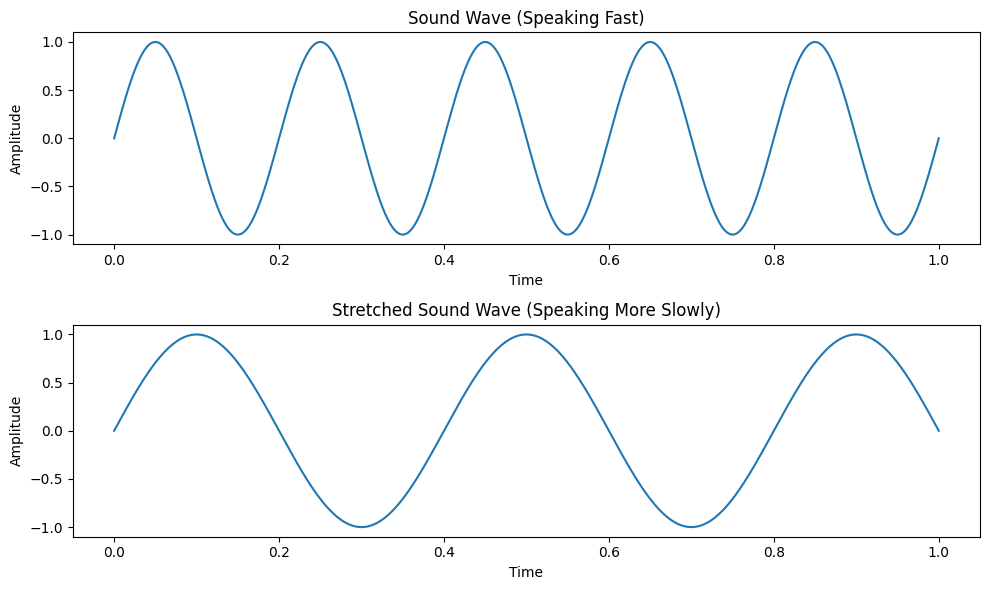

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generating a simple sound wave as an example
t = np.linspace(0, 1, 1000)
sound_wave_fast = np.sin(2 * np.pi * 5 * t)  # 5 Hz tone

# Stretching the sound wave to simulate speaking more slowly
# We'll simulate this by reducing the frequency
sound_wave_slow = np.sin(2 * np.pi * 2.5 * t)  # 2.5 Hz tone, half the original frequency

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the fast speaking sound wave
axs[0].plot(t, sound_wave_fast)
axs[0].set_title('Sound Wave (Speaking Fast)')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Amplitude')

# Plotting the stretched sound wave (speaking more slowly)
axs[1].plot(t, sound_wave_slow)
axs[1].set_title('Stretched Sound Wave (Speaking More Slowly)')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

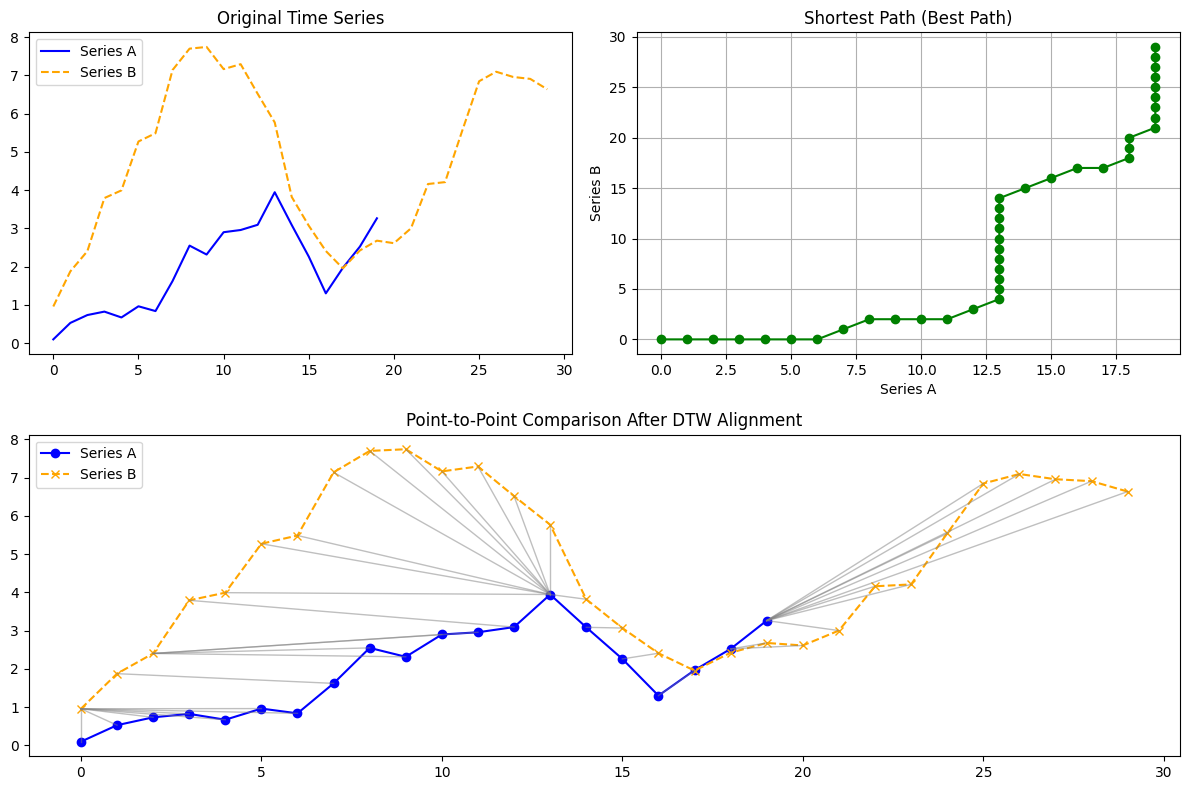

,Metric,Value,Description
0,DTW Similarity Score,0.306018,Lower scores indicate greater similarity betwe...


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from dtaidistance import dtw
from scipy.stats import pearsonr
import pandas as pd

# Generate dummy data for the time series

np.random.seed(0)
time_series_a = np.cumsum(np.random.rand(20) * 2 - 1)
time_series_b = np.cumsum(np.random.rand(30) * 2 - 1 + np.sin(np.linspace(0, 3 * np.pi, 30)))

# Calculate DTW distance and obtain the warping paths (no need for the C library)
distance, paths = dtw.warping_paths(time_series_a, time_series_b, use_c=False)
best_path = dtw.best_path(paths)

similarity_score = distance / len(best_path)

plt.figure(figsize=(12, 8))

# Original Time Series Plot
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(time_series_a, label='Series A', color='blue')
ax1.plot(time_series_b, label='Series B', linestyle='--',color='orange')
ax1.set_title('Original Time Series')
ax1.legend()

# Shortest Path Plot (Cost Matrix with the path)
# In this example, only the path is plotted, not the entire cost matrix.

ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(np.array(best_path)[:, 0], np.array(best_path)[:, 1], 'green', marker='o', linestyle='-')
ax2.set_title('Shortest Path (Best Path)')
ax2.set_xlabel('Series A')
ax2.set_ylabel('Series B')
ax2.grid(True)


# Point-to-Point Comparison Plot
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.plot(time_series_a, label='Series A', color='blue', marker='o')
ax3.plot(time_series_b, label='Series B', color='orange', marker='x', linestyle='--')
for a, b in best_path:
    ax3.plot([a, b], [time_series_a[a], time_series_b[b]], color='grey', linestyle='-', linewidth=1, alpha = 0.5)
ax3.set_title('Point-to-Point Comparison After DTW Alignment')
ax3.legend()

plt.tight_layout()
plt.show()

# Create a DataFrame to display the similarity score and correlation coefficient
results_df = pd.DataFrame({
    'Metric': ['DTW Similarity Score'],
    'Value': [similarity_score]
})

# Add descriptions for the results
results_df['Description'] = [
    "Lower scores indicate greater similarity between the time series."
]

results_df

In [2]:
# DTW comparison for two "hello" recordings (Colab-ready)
# Option 2: Clean audio-friendly layout + original visualizations adapted

# Install required packages (Colab)
!pip install -q dtaidistance librosa soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 34.2 MB/s eta 0:00:00


In [ ]:
# -------------------------
# (NEW) Proper comparable waveform visualization — same time axis
# -------------------------

# Determine the longer duration
max_len = max(len(sig1_norm), len(sig2_norm))

# Pad both signals to match length
sig1_pad = np.pad(sig1_norm, (0, max_len - len(sig1_norm)), mode='constant')
sig2_pad = np.pad(sig2_norm, (0, max_len - len(sig2_norm)), mode='constant')

# Create shared time axis in seconds
time_axis = np.linspace(0, max_len / TARGET_SR, max_len)

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(time_axis, sig1_pad, color='blue')
plt.title("Signal 1 — Your Voice (Padded, Normalized, Same Timeline)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(time_axis, sig2_pad, color='orange')
plt.title("Signal 2 — Friend's Voice (Padded, Normalized, Same Timeline)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


Upload: Signal 1 (your voice saying 'hello'):


Saving hello1.opus to hello1 (2).opus

Upload: Signal 2 (friend's voice saying 'hello'):


Saving hello2.opus to hello2 (2).opus

Loaded audio: 'hello1 (2).opus' (21085 samples, 16000 Hz), 'hello2 (2).opus' (16925 samples, 16000 Hz)
After trim: Signal1 length 19037 samples, Signal2 length 8704 samples


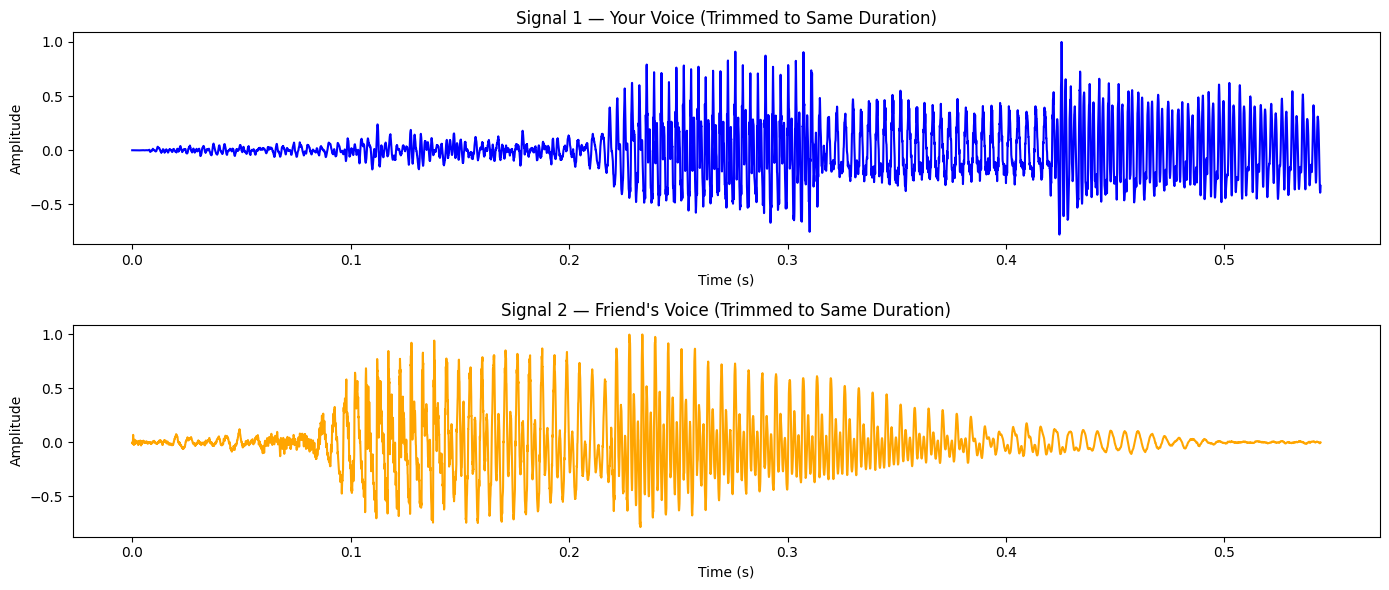

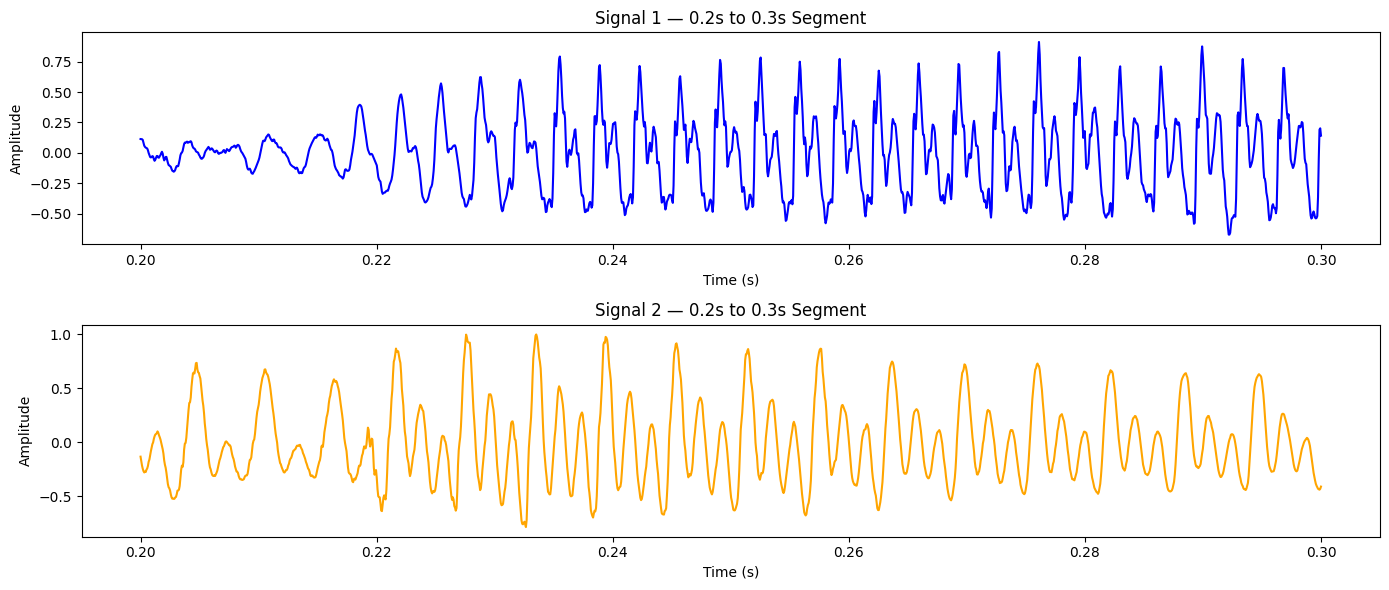


DTW total cost (distance): 5.147
DTW similarity score: 0.002065
Path length: 2492


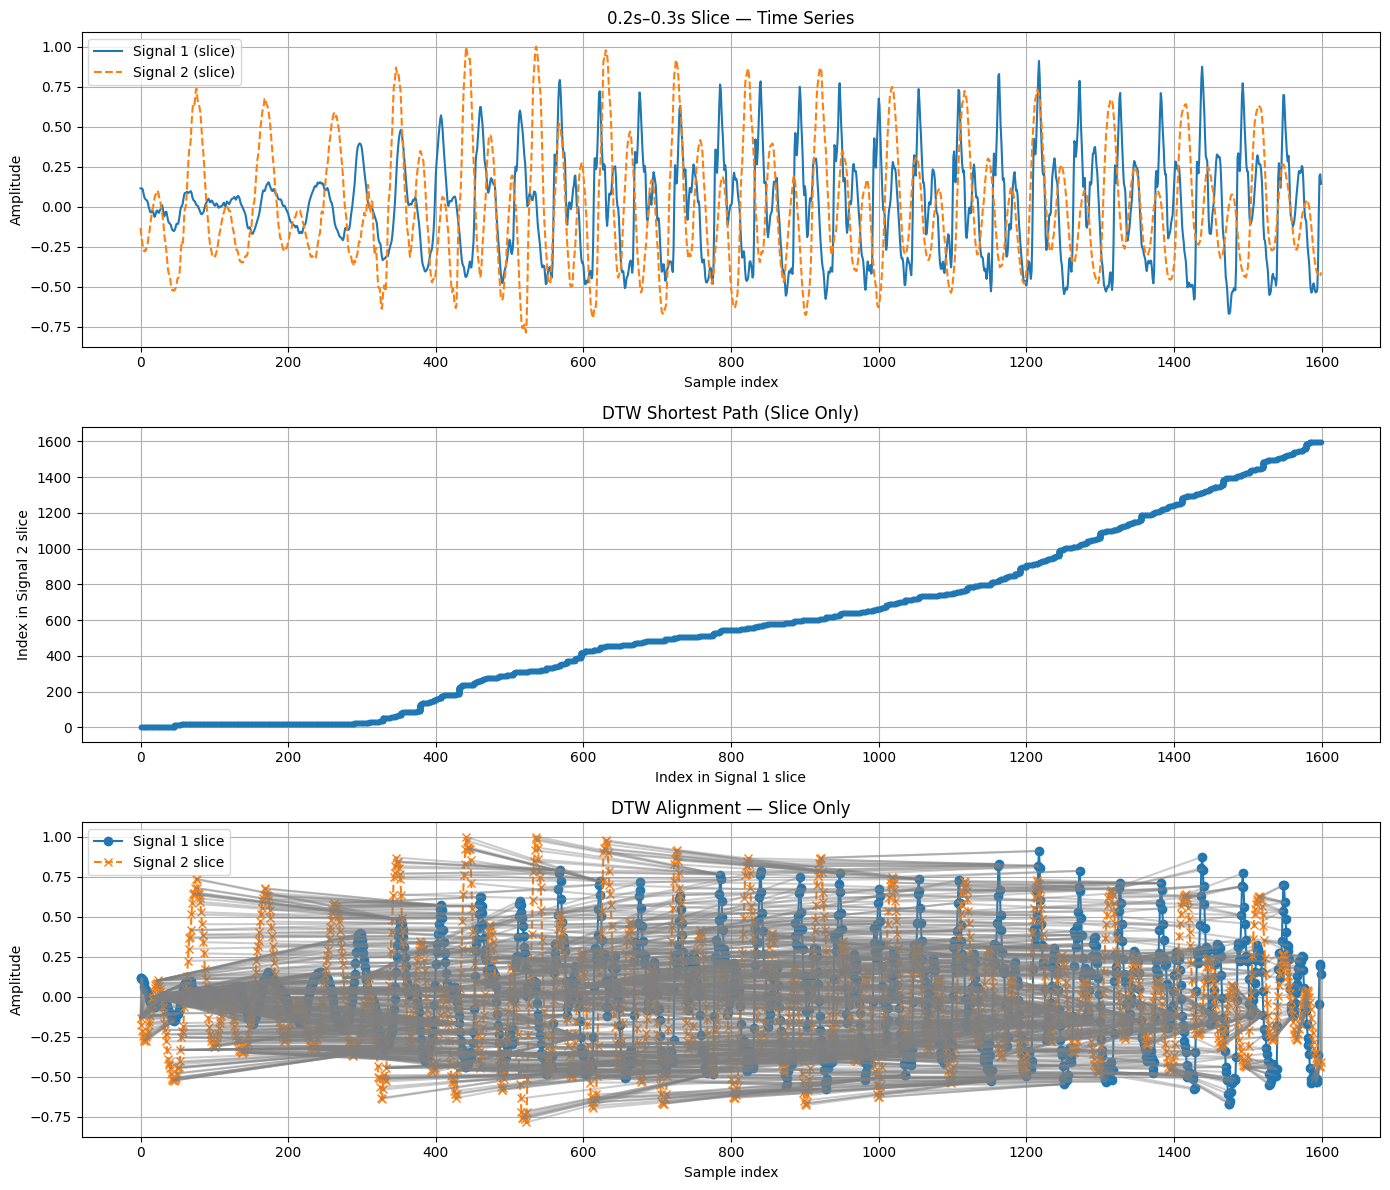

<Figure size 800x800 with 0 Axes>

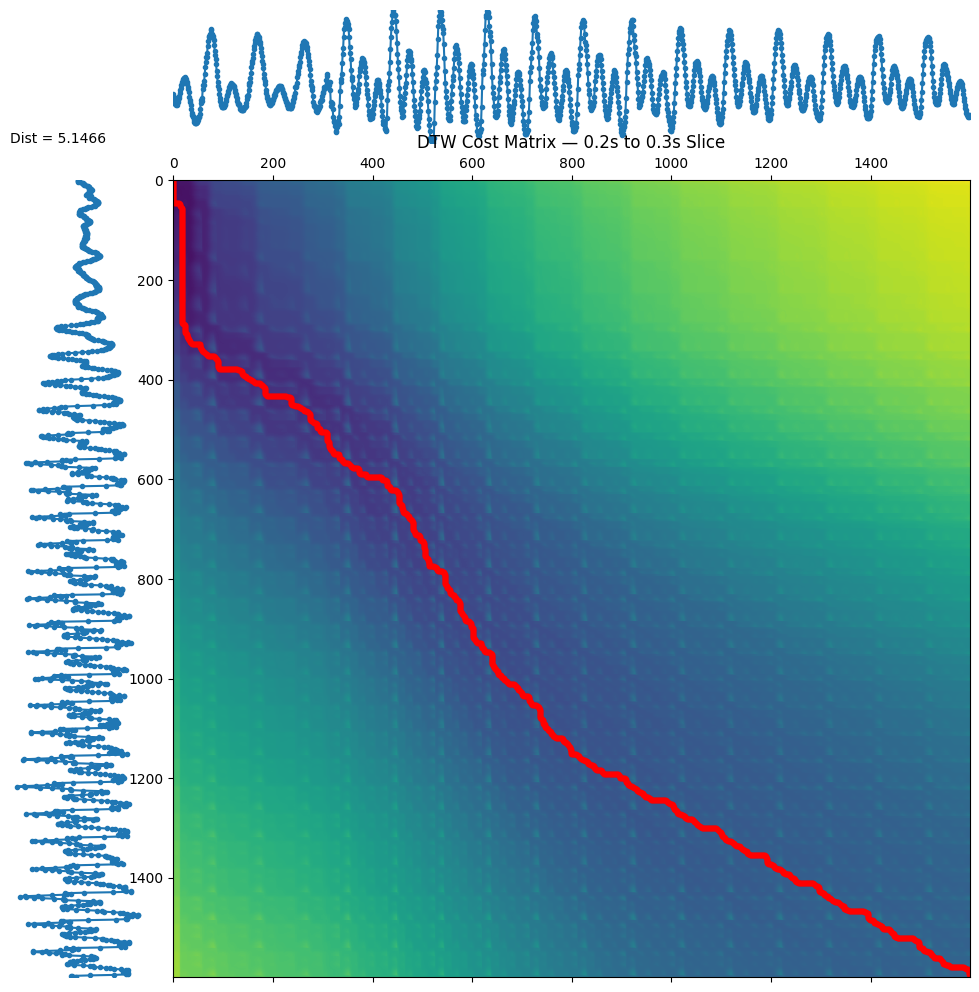


Aligned-slice Pearson correlation: 0.9496
Aligned-slice RMSE: 0.103098


,Metric,Value,Meaning
0,DTW distance (slice),5.146639,Lower → more similar on 0.2–0.3s segment.
1,Similarity score,0.002065,Normalized distance. Lower = better match.
2,Pearson correlation (aligned slice),0.949622,1.0 means signals are highly similar after DTW.
3,RMSE (aligned slice),0.103098,Lower RMSE means better alignment.
4,DTW path length (slice),2492.000000,How many pairs DTW matched in the slice.


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
from google.colab import files
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 1) Upload two audio files
# -------------------------
print("Upload: Signal 1 (your voice saying 'hello'):")
uploaded_1 = files.upload()
file1 = list(uploaded_1.keys())[0]

print("\nUpload: Signal 2 (friend's voice saying 'hello'):")
uploaded_2 = files.upload()
file2 = list(uploaded_2.keys())[0]

# -------------------------
# 2) Load audio (resample to 16 kHz)
# -------------------------
TARGET_SR = 16000

sig1, sr1 = librosa.load(file1, sr=TARGET_SR)
sig2, sr2 = librosa.load(file2, sr=TARGET_SR)
print(f"\nLoaded audio: '{file1}' ({len(sig1)} samples, {sr1} Hz), '{file2}' ({len(sig2)} samples, {sr2} Hz)")

# -------------------------
# 3) Trim leading/trailing silence
# -------------------------
sig1_trimmed, idx1 = librosa.effects.trim(sig1, top_db=30)
sig2_trimmed, idx2 = librosa.effects.trim(sig2, top_db=30)

sig1_use = sig1_trimmed
sig2_use = sig2_trimmed

print(f"After trim: Signal1 length {len(sig1_use)} samples, Signal2 length {len(sig2_use)} samples")

# -------------------------
# 4) Normalize signals
# -------------------------
def peak_normalize(x):
    if np.max(np.abs(x)) == 0:
        return x
    return x / np.max(np.abs(x))

sig1_norm = peak_normalize(sig1_use)
sig2_norm = peak_normalize(sig2_use)

# -------------------------
# 5) Clean waveform comparison (same duration, no padding)
# -------------------------
min_len = min(len(sig1_norm), len(sig2_norm))

sig1_section = sig1_norm[:min_len]
sig2_section = sig2_norm[:min_len]

time_axis = np.linspace(0, min_len / TARGET_SR, min_len)

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(time_axis, sig1_section, color='blue')
plt.title("Signal 1 — Your Voice (Trimmed to Same Duration)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(time_axis, sig2_section, color='orange')
plt.title("Signal 2 — Friend's Voice (Trimmed to Same Duration)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# -------------------------
# 6) Extract 0.2s to 0.3s segment for further analysis
# -------------------------
start_time = 0.2
end_time = 0.3

start_idx = int(start_time * TARGET_SR)
end_idx = int(end_time * TARGET_SR)
end_idx = min(end_idx, min_len)

sig1_slice = sig1_norm[start_idx:end_idx]
sig2_slice = sig2_norm[start_idx:end_idx]

slice_time = np.linspace(start_time, end_time, len(sig1_slice))

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(slice_time, sig1_slice, color='blue')
plt.title("Signal 1 — 0.2s to 0.3s Segment")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
plt.plot(slice_time, sig2_slice, color='orange')
plt.title("Signal 2 — 0.2s to 0.3s Segment")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# -------------------------
# 7) DTW ONLY on the trimmed slice
# -------------------------
distance, paths = dtw.warping_paths(sig1_slice, sig2_slice, use_c=False)
best_path = dtw.best_path(paths)

similarity_score = distance / max(1, len(best_path))

print(f"\nDTW total cost (distance): {distance:.3f}")
print(f"DTW similarity score: {similarity_score:.6f}")
print(f"Path length: {len(best_path)}")

# -------------------------
# 8) 3-panel visualization (using only slices)
# -------------------------
fig = plt.figure(figsize=(14,12))

# Panel A: Slice time series
ax1 = plt.subplot2grid((3,2), (0,0), colspan=2)
ax1.plot(np.arange(len(sig1_slice)), sig1_slice, label='Signal 1 (slice)')
ax1.plot(np.arange(len(sig2_slice)), sig2_slice, label='Signal 2 (slice)', linestyle='--')
ax1.set_title("0.2s–0.3s Slice — Time Series")
ax1.set_xlabel("Sample index")
ax1.set_ylabel("Amplitude")
ax1.legend()
ax1.grid(True)

# Panel B: Warping path
ax2 = plt.subplot2grid((3,2), (1,0), colspan=2)
path_arr = np.array(best_path)
ax2.plot(path_arr[:,0], path_arr[:,1], marker='o', linestyle='-', markersize=3)
ax2.set_title("DTW Shortest Path (Slice Only)")
ax2.set_xlabel("Index in Signal 1 slice")
ax2.set_ylabel("Index in Signal 2 slice")
ax2.grid(True)

# Panel C: Point-to-point alignment
ax3 = plt.subplot2grid((3,2), (2,0), colspan=2)
ax3.plot(sig1_slice, label='Signal 1 slice', marker='o')
ax3.plot(sig2_slice, label='Signal 2 slice', marker='x', linestyle='--')
for i, j in best_path:
    ax3.plot([i,j], [sig1_slice[i], sig2_slice[j]], color='gray', alpha=0.4)
ax3.set_title("DTW Alignment — Slice Only")
ax3.set_xlabel("Sample index")
ax3.set_ylabel("Amplitude")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

# -------------------------
# 9) Cost matrix (slice only)
# -------------------------
plt.figure(figsize=(8,8))
dtwvis.plot_warpingpaths(sig1_slice, sig2_slice, paths, best_path)
plt.title("DTW Cost Matrix — 0.2s to 0.3s Slice")
plt.show()

# -------------------------
# 10) Compute correlation/RMSE on slice alignment
# -------------------------
aligned_1 = []
aligned_2 = []

for i, j in best_path:
    aligned_1.append(sig1_slice[i])
    aligned_2.append(sig2_slice[j])

aligned_1 = np.array(aligned_1)
aligned_2 = np.array(aligned_2)

if len(aligned_1) > 1:
    corr_coef = np.corrcoef(aligned_1, aligned_2)[0,1]
else:
    corr_coef = np.nan

rmse = np.sqrt(np.mean((aligned_1 - aligned_2)**2))

print(f"\nAligned-slice Pearson correlation: {corr_coef:.4f}")
print(f"Aligned-slice RMSE: {rmse:.6f}")

# -------------------------
# 11) Summary table
# -------------------------
results_df = pd.DataFrame({
    "Metric": ["DTW distance (slice)", "Similarity score",
               "Pearson correlation (aligned slice)", "RMSE (aligned slice)",
               "DTW path length (slice)"],
    "Value": [distance, similarity_score, corr_coef, rmse, len(best_path)]
})

results_df["Meaning"] = [
    "Lower → more similar on 0.2–0.3s segment.",
    "Normalized distance. Lower = better match.",
    "1.0 means signals are highly similar after DTW.",
    "Lower RMSE means better alignment.",
    "How many pairs DTW matched in the slice."
]

display(results_df)
